$log(risk) = b_0 + b_1 forklift\\speed\\kmh $

In [56]:
# log of risk (strictly positive)
df["log_risk"] = np.log(df["safety_risk_index"])

X = df[["forklift_speed_kmh"]]
y_log = df["log_risk"]

X_const = sm.add_constant(X)
model_log = sm.OLS(y_log, X_const).fit()

print(model_log.summary())


                            OLS Regression Results                            
Dep. Variable:               log_risk   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     225.7
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           1.52e-34
Time:                        20:45:44   Log-Likelihood:                 169.03
No. Observations:                 200   AIC:                            -334.1
Df Residuals:                     198   BIC:                            -327.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.9857      0

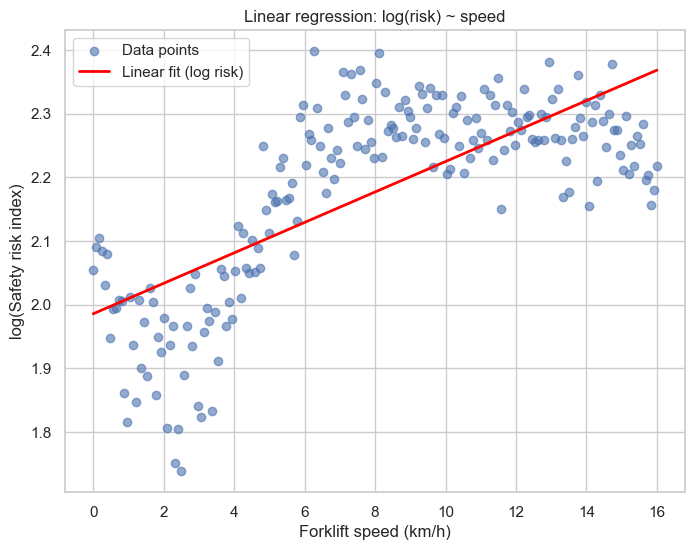

In [57]:
# Plot log(risk) vs speed with linear fit
plt.figure(figsize=(8, 6))
plt.scatter(df["forklift_speed_kmh"], df["log_risk"],
            alpha=0.6, label="Data points")

y_log_pred = model_log.predict(X_const)
sorted_idx = np.argsort(df["forklift_speed_kmh"])
speed_sorted = df["forklift_speed_kmh"].iloc[sorted_idx]
y_log_pred_sorted = y_log_pred.iloc[sorted_idx]

plt.plot(speed_sorted, y_log_pred_sorted,
         color="red", linewidth=2, label="Linear fit (log risk)")
plt.xlabel("Forklift speed (km/h)")
plt.ylabel("log(Safety risk index)")
plt.title("Linear regression: log(risk) ~ speed")
plt.legend()
plt.show()


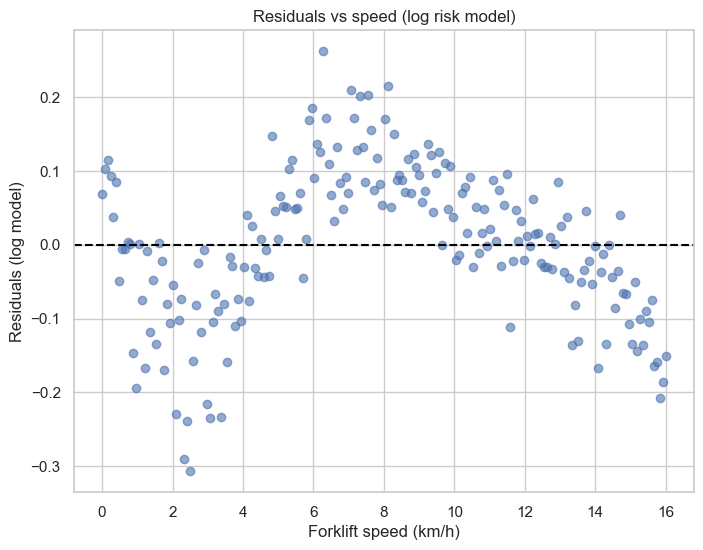

In [58]:
# Residuals for log model
residuals_log = y_log - y_log_pred

plt.figure(figsize=(8, 6))
plt.scatter(df["forklift_speed_kmh"], residuals_log,
            alpha=0.6)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Forklift speed (km/h)")
plt.ylabel("Residuals (log model)")
plt.title("Residuals vs speed (log risk model)")
plt.show()
